In [1]:
import glob
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from quantnado import BamStore

/ceph/project/milne_group/cchahrou/software/miniforge3/envs/quantnado/lib/python3.13/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Make Zarr Dataset
This notebook makes, loads, and explores the Zarr xarray dataset created from BAM files.

In [2]:
# # Setup paths and parameters
# data_dir = "/Users/catherine/work/project/QuantNado/data/2025-12-17_menin_inh_24hr"
# metadata_files = sorted(glob.glob(f"{data_dir}/metadata_*.csv"))
# chrom_sizes_path = "/Users/catherine/work/project/QuantNado/data/hg38/hg38.chrom.sizes"
# bam_files = sorted(glob.glob(f"{data_dir}/seqnado_output/**/aligned/SEM*.bam"))
# print("Found", len(bam_files), "BAM Files")

In [3]:
bam_files = list(Path("/ceph/project/milne_group/cchahrou/processed_data/seqnado_output/cat/aligned").glob("*.bam"))
bam_files

[PosixPath('/ceph/project/milne_group/cchahrou/processed_data/seqnado_output/cat/aligned/CAT-patient-9422-2_MLLN.bam'),
 PosixPath('/ceph/project/milne_group/cchahrou/processed_data/seqnado_output/cat/aligned/CAT-patient-9422_H3K4me1.bam'),
 PosixPath('/ceph/project/milne_group/cchahrou/processed_data/seqnado_output/cat/aligned/CAT-patient-9422_p300.bam')]

In [4]:
# bam_files = list(Path("/Users/asmith/Documents/2025-oxford-postdoc/2025-01-cancer-specific-enhancers/2024-12-16-specific-enhancer-identification/data/raw/h3k27ac/").glob("*.bam"))
# bam_files

## Process BAM files to Zarr

Process each BAM file using the parallel chromosome processing:

In [5]:
store = BamStore.from_bam_files(
    bam_files=[str(p) for p in bam_files],
    store_path='test_bam_store.zarr',
    chunk_len=2_000_000,
)

2026-02-22 12:55:17.465 | INFO     | quantnado.dataset.bam:from_bam_files:454 - Extracting chromsizes from /ceph/project/milne_group/cchahrou/processed_data/seqnado_output/cat/aligned/CAT-patient-9422-2_MLLN.bam
2026-02-22 12:55:17.486 | WARNING  | quantnado.dataset.bam:__init__:175 - Deleting existing store at: test_bam_store.zarr
2026-02-22 12:55:23.411 | INFO     | quantnado.dataset.bam:_init_store:292 - Initialized Zarr store at test_bam_store.zarr
2026-02-22 12:55:23.416 | INFO     | quantnado.dataset.bam:process_samples:401 - Processing sample 1/3: CAT-patient-9422-2_MLLN
2026-02-22 12:56:26.311 | INFO     | quantnado.dataset.bam:process_samples:401 - Processing sample 2/3: CAT-patient-9422_H3K4me1
2026-02-22 12:57:34.277 | INFO     | quantnado.dataset.bam:process_samples:401 - Processing sample 3/3: CAT-patient-9422_p300


In [6]:
store = BamStore.open('test_bam_store.zarr', read_only=False)
store.update_metadata({"test": np.random.randint(0, 100, store.n_samples)})
store.get_metadata()

2026-02-22 12:58:44.345 | INFO     | quantnado.dataset.bam:_load_existing:298 - Resuming existing store at test_bam_store.zarr
2026-02-22 12:58:44.384 | INFO     | quantnado.dataset.bam:update_metadata:655 - Updated metadata column: test


,test,sample_hash,completed,sparsity
sample_id,,,,
CAT-patient-9422-2_MLLN,90,52dba6f6985ed2881cd77527a9380b93,True,48.712582
CAT-patient-9422_H3K4me1,25,84685fbc9ecd97edb5a6c194310d9c1e,True,60.757053
CAT-patient-9422_p300,5,042364846b080aa27aaab5724b770d6b,True,53.691933


In [7]:
store.remove_metadata_columns(['test'])
store.get_metadata()

2026-02-22 12:58:44.539 | INFO     | quantnado.dataset.bam:remove_metadata_columns:555 - Removed metadata column: test


,sample_hash,completed,sparsity
sample_id,,,
CAT-patient-9422-2_MLLN,52dba6f6985ed2881cd77527a9380b93,True,48.712582
CAT-patient-9422_H3K4me1,84685fbc9ecd97edb5a6c194310d9c1e,True,60.757053
CAT-patient-9422_p300,042364846b080aa27aaab5724b770d6b,True,53.691933


# Create Xarray dataset from BamStore

In [8]:
chrom = store.to_xarray(chromosomes=['chr1'])

2026-02-22 12:58:46.474 | INFO     | quantnado.dataset.bam:to_xarray:784 - Extracted 1 chromosomes as Xarray DataArrays with 3 metadata columns


In [10]:
X = chrom['chr1'].sel(sample=['CAT-patient-9422-2_MLLN'], position=slice(500_000, 590_000)).compute()

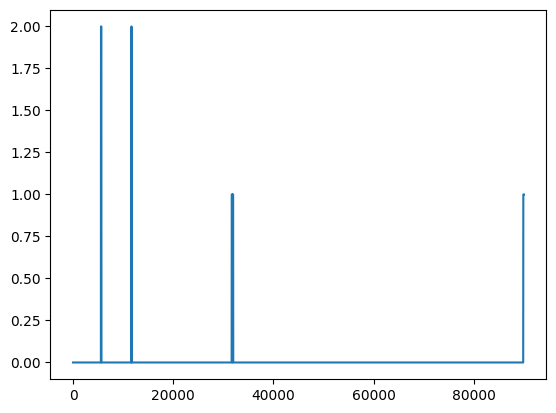

In [11]:
plt.plot(X.values[0])

2026-02-22 12:59:51.232 | INFO     | quantnado.dataset.bam:extract_region:958 - Extracted region chr9:77418764-78339335 (920571 bp) for 3 sample(s)


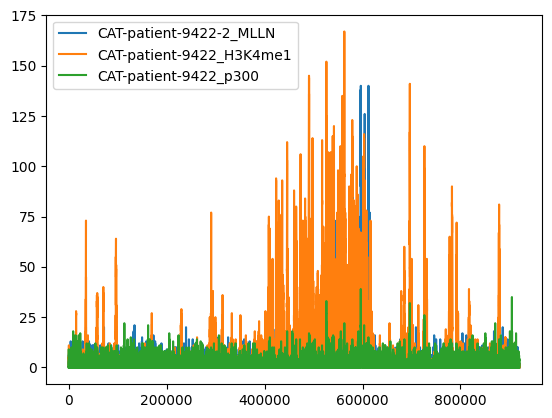

In [12]:
ds = store.extract_region("chr9:77,418,764-78,339,335")
samples = ds.sample.values
y = ds.values

for i, sample in enumerate(samples):
    plt.plot(y[i], label=sample)

plt.legend()

# Try reduce and PCA

In [13]:
from quantnado import QuantNado

In [14]:
qn = QuantNado.open("test_bam_store.zarr")

2026-02-22 13:00:02.074 | INFO     | quantnado.dataset.bam:_load_existing:298 - Resuming existing store at test_bam_store.zarr


In [16]:
# Try extract method
extracted_signal = qn.extract(gtf_path="/ceph/project/milne_group/shared/seqnado_reference/hg38/UCSC/genes/hg38.ncbiRefSeq.gtf", feature_type="promoter", fixed_width=2000)


2026-02-22 13:01:25.124 | WARNING  | quantnado.dataset.features:extract_promoters:209 - No 'gene' features found in GTF; falling back to 'transcript'
2026-02-22 13:01:37.502 | INFO     | quantnado.dataset.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 25 shared chromosomes out of 539 in GTF and 25 in dataset
2026-02-22 13:01:37.503 | DEBUG    | quantnado.dataset.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrX', 'chrY']
2026-02-22 13:01:37.504 | WARNING  | quantnado.dataset.reduce:_log_chromosome_overlap:69 - GTF contains 514 chromosome(s) not in dataset: ['chr10_GL383545v1_alt', 'chr10_GL383546v1_alt', 'chr10_KI270824v1_alt', 'chr10_KN196480v1_fix', 'chr10_KN538366v1_fix', 'chr10_KQ090020v1_alt', 'chr10_KQ090021v1_fix', 'chr10_ML143354v1_fix', 'chr10_ML1433

In [17]:
extracted_signal


<xarray.DataArray 'getitem-43afecdaca517fddc93c37dc1987d987' (interval: 191564,
                                                              relative_position: 2000,
                                                              sample: 3)> Size: 5GB
dask.array<getitem, shape=(191564, 2000, 3), dtype=float32, chunksize=(652, 2000, 1), chunktype=numpy.ndarray>
Coordinates:
  * interval           (interval) int64 2MB 0 1 2 3 ... 191561 191562 191563
    start              (interval) int64 2MB 248935570 248873247 ... 275997
    end                (interval) int64 2MB 248936770 248874447 ... 277197
    contig             (interval) <U5 4MB 'chr1' 'chr1' 'chr1' ... 'chrY' 'chrY'
    strand             (interval) object 2MB '+' '+' '+' '+' ... '-' '-' '-' '-'
  * relative_position  (relative_position) int64 16kB 0 1 2 3 ... 1997 1998 1999
  * sample             (sample) <U24 288B 'CAT-patient-9422-2_MLLN' ... 'CAT-...
Attributes:
    fixed_width:  2000
    anchor:       midpoint
    bin_size:     None
    bin_agg:      None

In [18]:
# Test with binning
binned_signal = qn.extract(gtf_path="/ceph/project/milne_group/shared/seqnado_reference/hg38/UCSC/genes/hg38.ncbiRefSeq.gtf", feature_type="promoter", fixed_width=2000, bin_size=50, bin_agg="mean")
binned_signal


2026-02-22 13:05:06.775 | WARNING  | quantnado.dataset.features:extract_promoters:209 - No 'gene' features found in GTF; falling back to 'transcript'
2026-02-22 13:05:19.070 | INFO     | quantnado.dataset.reduce:_log_chromosome_overlap:60 - Chromosome compatibility check: 25 shared chromosomes out of 539 in GTF and 25 in dataset
2026-02-22 13:05:19.071 | DEBUG    | quantnado.dataset.reduce:_log_chromosome_overlap:66 - Shared chromosomes: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrX', 'chrY']
2026-02-22 13:05:19.072 | WARNING  | quantnado.dataset.reduce:_log_chromosome_overlap:69 - GTF contains 514 chromosome(s) not in dataset: ['chr10_GL383545v1_alt', 'chr10_GL383546v1_alt', 'chr10_KI270824v1_alt', 'chr10_KN196480v1_fix', 'chr10_KN538366v1_fix', 'chr10_KQ090020v1_alt', 'chr10_KQ090021v1_fix', 'chr10_ML143354v1_fix', 'chr10_ML1433

<xarray.DataArray 'getitem-100c93157b79d0cabfc3bb3dc4c758bc' (interval: 191564,
                                                              bin: 40, sample: 3)> Size: 92MB
dask.array<getitem, shape=(191564, 40, 3), dtype=float32, chunksize=(652, 40, 1), chunktype=numpy.ndarray>
Coordinates:
  * interval  (interval) int64 2MB 0 1 2 3 4 ... 191560 191561 191562 191563
    start     (interval) int64 2MB 248935570 248873247 ... 317796 275997
    end       (interval) int64 2MB 248936770 248874447 ... 318996 277197
    contig    (interval) <U5 4MB 'chr1' 'chr1' 'chr1' ... 'chrY' 'chrY' 'chrY'
    strand    (interval) object 2MB '+' '+' '+' '+' '+' ... '-' '-' '-' '-' '-'
  * bin       (bin) int64 320B 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 39
  * sample    (sample) <U24 288B 'CAT-patient-9422-2_MLLN' ... 'CAT-patient-9...
Attributes:
    fixed_width:  2000
    anchor:       midpoint
    bin_size:     50
    bin_agg:      mean

In [19]:
# Filter extracted signal by strand
if "strand" in extracted_signal.coords:
    plus_strand = extracted_signal.sel(interval=(extracted_signal.coords["strand"] == "+"))
    minus_strand = extracted_signal.sel(interval=(extracted_signal.coords["strand"] == "-"))
    print(f"Plus-strand intervals: {len(plus_strand.coords['interval'])}")
    print(f"Minus-strand intervals: {len(minus_strand.coords['interval'])}")


Plus-strand intervals: 97465
Minus-strand intervals: 94099
